# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram
sns.set_theme(style="whitegrid"); RANDOM_STATE=42

### Leer conjunto de datos y primer vistazo

In [2]:
df=pd.read_csv("data/credit_card.csv"); df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [3]:
print(df.shape)

(8950, 18)


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [5]:
df.dtypes.to_frame("tipo")

,tipo
CUST_ID,str
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


#### Nulos

In [6]:
df.isna().sum().loc[lambda x:x>0]

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [7]:
df=df.drop(columns="CUST_ID").fillna(df.drop(columns="CUST_ID").median(numeric_only=True)); print(df.isna().sum().sum())

0


#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

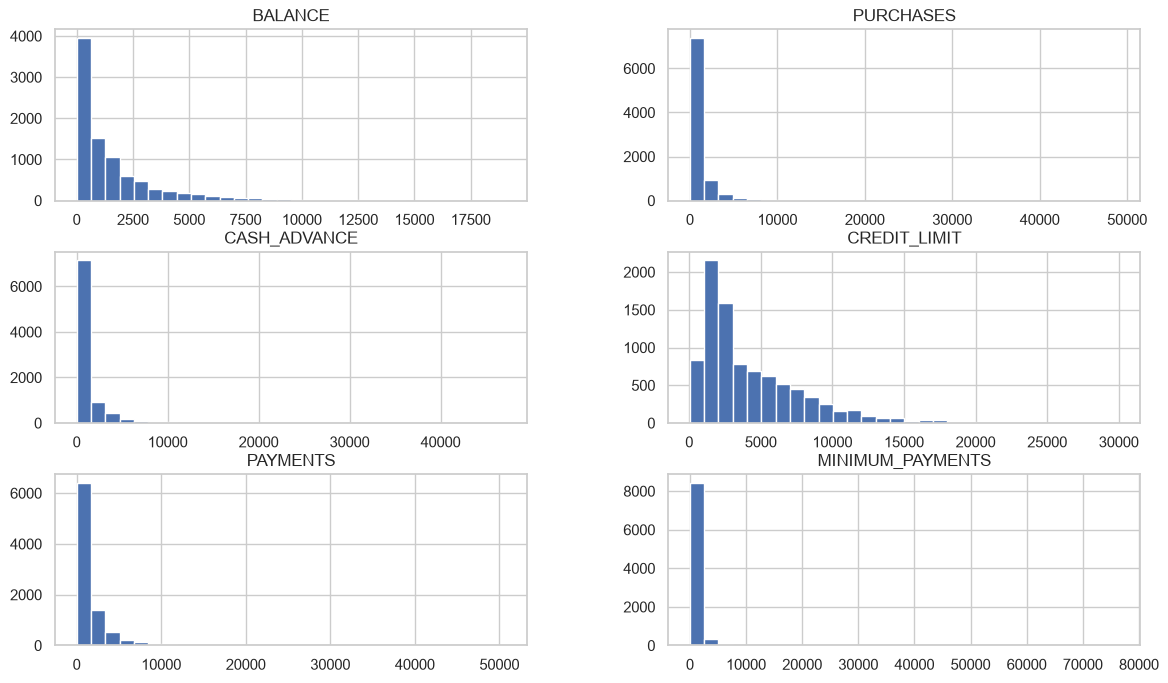

In [8]:
cols=["BALANCE","PURCHASES","CASH_ADVANCE","CREDIT_LIMIT","PAYMENTS","MINIMUM_PAYMENTS"]; df[cols].hist(figsize=(14,8),bins=30); plt.show()

### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [9]:
scaler=StandardScaler(); X=scaler.fit_transform(df); print(X.mean(axis=0).round(5))

[ 0.  0.  0.  0.  0.  0. -0. -0.  0.  0. -0. -0.  0. -0.  0.  0.  0.]


## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

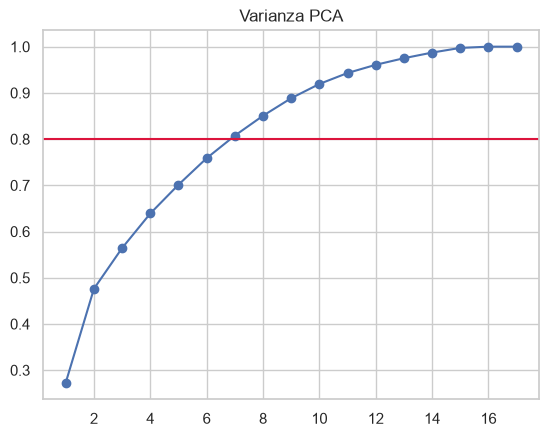

7


In [10]:
pca_full=PCA(random_state=RANDOM_STATE).fit(X); cumulative_variance=np.cumsum(pca_full.explained_variance_ratio_); n_components_80=np.argmax(cumulative_variance>=.8)+1; plt.plot(range(1,len(cumulative_variance)+1),cumulative_variance,marker="o"); plt.axhline(.8,c="crimson"); plt.title("Varianza PCA"); plt.show(); print(n_components_80)

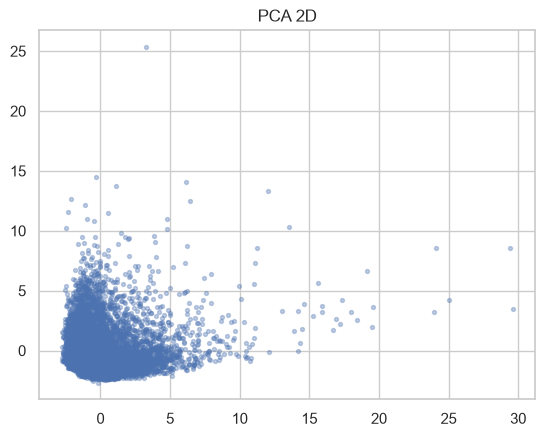

In [11]:
pca_2=PCA(2,random_state=RANDOM_STATE); X_pca_2=pca_2.fit_transform(X); plt.scatter(X_pca_2[:,0],X_pca_2[:,1],s=8,alpha=.35); plt.title("PCA 2D"); plt.show()

A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

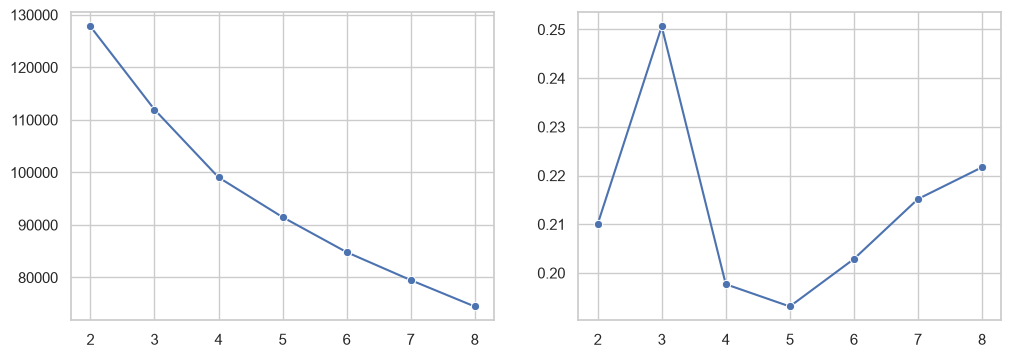

3


In [12]:
k_values=range(2,9); inercias=[]; silhouettes=[]
for k in k_values:
 km=KMeans(k,n_init=20,random_state=RANDOM_STATE).fit(X); inercias.append(km.inertia_); silhouettes.append(silhouette_score(X,km.labels_))
best_k=list(k_values)[int(np.argmax(silhouettes))]; fig,ax=plt.subplots(1,2,figsize=(12,4)); sns.lineplot(x=list(k_values),y=inercias,marker="o",ax=ax[0]); sns.lineplot(x=list(k_values),y=silhouettes,marker="o",ax=ax[1]); plt.show(); print(best_k)

### K-Means final

In [13]:
kmeans=KMeans(best_k,n_init=20,random_state=RANDOM_STATE); labels_kmeans=kmeans.fit_predict(X); pd.Series(labels_kmeans).value_counts().sort_index()

0    6119
1    1235
2    1596
Name: count, dtype: int64

### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [14]:
def evaluar(nombre,labels,datos): return {"algoritmo":nombre,"silhouette":silhouette_score(datos,labels),"davies_bouldin":davies_bouldin_score(datos,labels),"calinski_harabasz":calinski_harabasz_score(datos,labels)}
idx=np.random.default_rng(RANDOM_STATE).choice(len(X),3000,replace=False); xs=X[idx]; pd.DataFrame([evaluar("KMeans",KMeans(best_k,n_init=20,random_state=RANDOM_STATE).fit_predict(xs),xs),evaluar("Aglomerativo",AgglomerativeClustering(best_k).fit_predict(xs),xs),evaluar("GMM",GaussianMixture(best_k,random_state=RANDOM_STATE).fit_predict(xs),xs)]).round(3)

,algoritmo,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,0.213,1.464,558.632
1,Aglomerativo,0.191,1.487,472.206
2,GMM,0.112,2.581,303.184


### Dendrograma

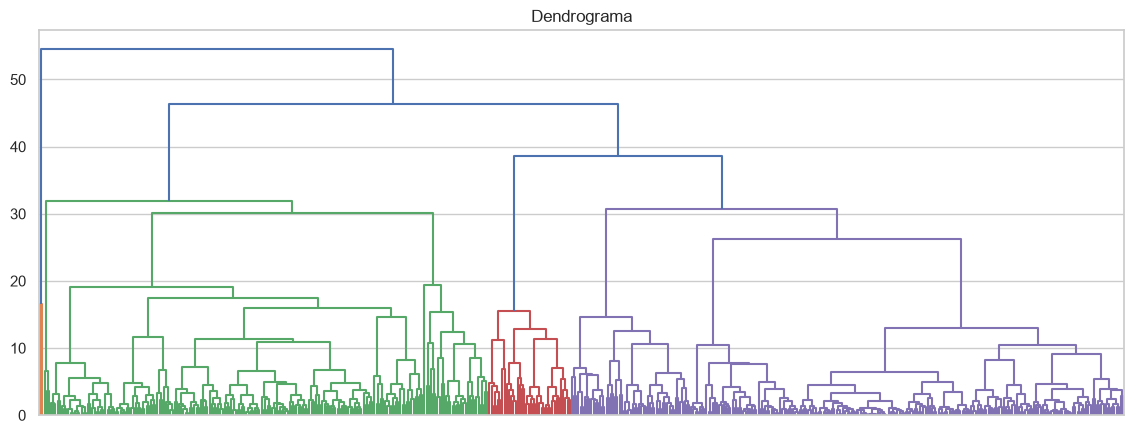

In [15]:
idx=np.random.default_rng(RANDOM_STATE).choice(len(X),500,replace=False); plt.figure(figsize=(14,5)); dendrogram(linkage(X[idx],method="ward"),no_labels=True); plt.title("Dendrograma"); plt.show()

### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

clusters 4 ruido 0.02670391061452514


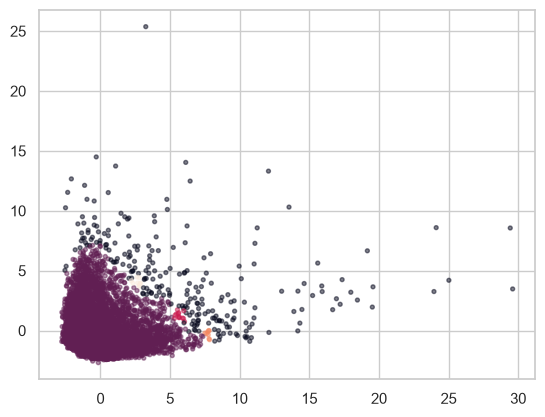

In [16]:
labels_dbscan=DBSCAN(eps=.5,min_samples=10).fit_predict(X_pca_2); print("clusters",len(set(labels_dbscan))-(-1 in labels_dbscan),"ruido",(labels_dbscan==-1).mean()); plt.scatter(X_pca_2[:,0],X_pca_2[:,1],c=labels_dbscan,s=8,alpha=.5); plt.show()

### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

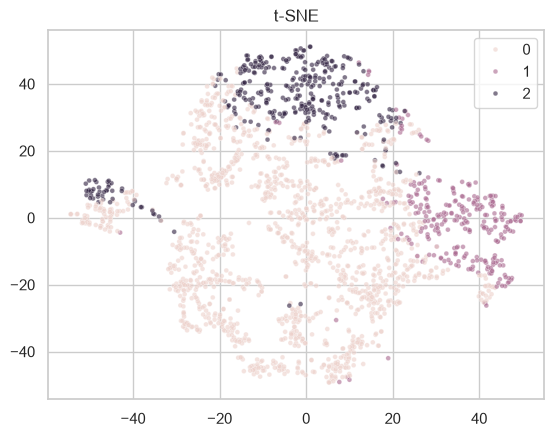

In [17]:
idx=np.random.default_rng(RANDOM_STATE).choice(len(X),2000,replace=False); emb=TSNE(2,random_state=RANDOM_STATE,init="pca",learning_rate="auto").fit_transform(X[idx]); sns.scatterplot(x=emb[:,0],y=emb[:,1],hue=labels_kmeans[idx],s=12,alpha=.6); plt.title("t-SNE"); plt.show()

## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

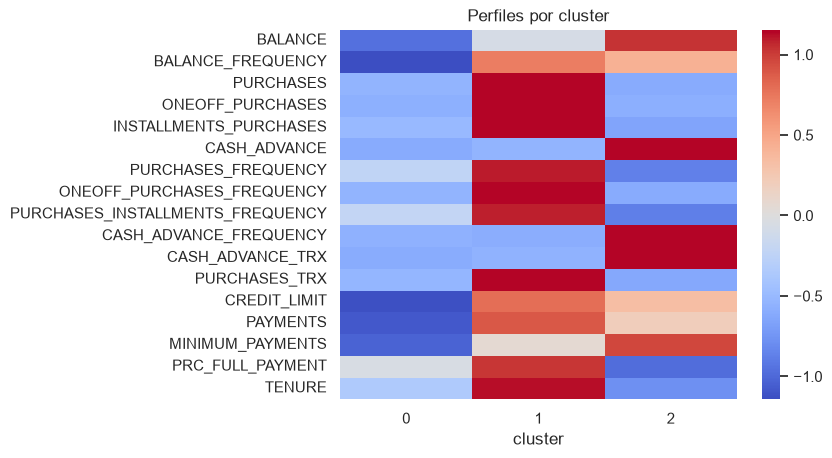

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,799.75,0.84,505.53,253.12,252.73,330.82,0.47,0.13,0.35,0.07,1.21,8.65,3271.51,909.68,523.21,0.16,11.48
1,2220.00,0.98,4268.52,2717.83,1551.18,458.42,0.95,0.67,0.74,0.06,1.53,56.47,7733.97,4151.28,1220.52,0.30,11.92
2,3989.14,0.96,384.53,248.72,135.89,3866.21,0.23,0.11,0.14,0.45,12.40,5.61,6675.44,3019.11,1787.62,0.03,11.35


In [18]:
df_clustered=df.copy(); df_clustered["cluster"]=labels_kmeans; profile_means=df_clustered.groupby("cluster").mean(); profile_z=(profile_means-profile_means.mean())/profile_means.std().replace(0,1); sns.heatmap(profile_z.T,cmap="coolwarm",center=0); plt.title("Perfiles por cluster"); plt.show(); profile_means.round(2)

Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

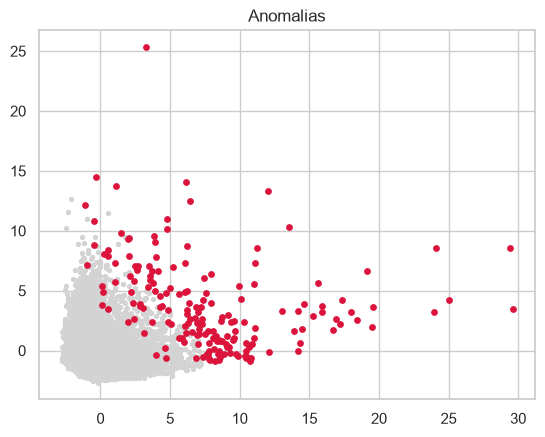

In [19]:
iso=IsolationForest(contamination=.02,random_state=RANDOM_STATE); anomaly_labels=iso.fit_predict(X); plt.scatter(X_pca_2[:,0],X_pca_2[:,1],s=8,c="lightgray"); plt.scatter(X_pca_2[anomaly_labels==-1,0],X_pca_2[anomaly_labels==-1,1],s=15,c="crimson"); plt.title("Anomalias"); plt.show()

## Para ir mas alla (opcional)
Incluye KPIs, transformaciones y metodos robustos ante estructuras no lineales.

In [ ]:
df_kpis=df.copy(); df_kpis["ratio_uso_limite"]=np.divide(df_kpis.BALANCE,df_kpis.CREDIT_LIMIT,out=np.zeros(len(df_kpis)),where=df_kpis.CREDIT_LIMIT.to_numpy()!=0); df_kpis["compra_media_por_transaccion"]=np.divide(df_kpis.PURCHASES,df_kpis.PURCHASES_TRX,out=np.zeros(len(df_kpis)),where=df_kpis.PURCHASES_TRX.to_numpy()!=0); monetary=["BALANCE","PURCHASES","CASH_ADVANCE","CREDIT_LIMIT","PAYMENTS","MINIMUM_PAYMENTS"]; df_log=df.copy(); df_log[monetary]=np.log1p(df_log[monetary]); df_kpis[["ratio_uso_limite","compra_media_por_transaccion"]].describe()

In [ ]:
try:
 import umap,hdbscan
except ImportError: print("Instala: pip install umap-learn hdbscan")
else:
 xlog=StandardScaler().fit_transform(df_log); u=umap.UMAP(random_state=RANDOM_STATE).fit_transform(xlog); h=hdbscan.HDBSCAN(min_cluster_size=60).fit_predict(xlog); sns.scatterplot(x=u[:,0],y=u[:,1],hue=h,s=10,legend=False); plt.title("UMAP + HDBSCAN"); plt.show()

## Conclusiones
Sin etiqueta, las metricas internas y perfiles interpretables justifican segmentos; los KPIs conectan el resultado con decisiones de negocio.